### Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Importing the dataset

In [2]:
df=pd.read_csv('IPL2025_Ball_Analysis.csv')
df

,Match Number,Match Date,Venue,City,Toss Winner,Toss Decision,Innings,Batting Team,Bowling Team,Batter,Bowler,Over,Ball,Score
0,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,1,•
1,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,2,4
2,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,3,•
3,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,4,•
4,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,5,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16237,Final,3 June 2025,Narendra Modi Stadium,Ahmedabad,PBKS,field,2,PBKS,RCB,Shashank Singh,Hazlewood,20,2,•
16238,Final,3 June 2025,Narendra Modi Stadium,Ahmedabad,PBKS,field,2,PBKS,RCB,Shashank Singh,Hazlewood,20,3,6
16239,Final,3 June 2025,Narendra Modi Stadium,Ahmedabad,PBKS,field,2,PBKS,RCB,Shashank Singh,Hazlewood,20,4,4
16240,Final,3 June 2025,Narendra Modi Stadium,Ahmedabad,PBKS,field,2,PBKS,RCB,Shashank Singh,Hazlewood,20,5,6


## **Problem Statement:**
The objective of this project is to analyze ball-by-ball data from the IPL 2025 season to understand match dynamics, team performance, player contributions, and strategic factors influencing match outcomes. By applying exploratory data analysis techniques to data collected through web scraping, the study aims to derive meaningful insights such as scoring patterns, effectiveness of toss decisions, phase-wise performance, tournament standings, and identification of top-performing players, as well as key tournament statistics such as Orange Cap, Purple Cap, and championship outcomes.

### Data Understanding

| Column        | Description                 |
| ------------- | --------------------------- |
| Match Number  | Match identifier            |
| Match Date    | Date of match               |
| Venue         | Stadium                     |
| City          | City of match               |
| Toss Winner   | Team that won toss          |
| Toss Decision | Bat / Field                 |
| Innings       | 1 or 2                      |
| Batting Team  | Team batting                |
| Bowling Team  | Team bowling                |
| Batter        | Batter Name on strike       |
| Bowler        | Bowler  Name                |
| Over          | Over number                 |
| Ball          | Ball number                 |
| Score         | Raw score notation (object) |


In [3]:
#Shape of the data
df.shape

(16242, 14)

**At initial stage the dataset contains `16242` records and `14` columns/fields.**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16242 entries, 0 to 16241
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Match Number   16242 non-null  object
 1   Match Date     16242 non-null  object
 2   Venue          16242 non-null  object
 3   City           16242 non-null  object
 4   Toss Winner    16242 non-null  object
 5   Toss Decision  16242 non-null  object
 6   Innings        16242 non-null  int64 
 7   Batting Team   16242 non-null  object
 8   Bowling Team   16242 non-null  object
 9   Batter         16242 non-null  object
 10  Bowler         16242 non-null  object
 11  Over           16242 non-null  int64 
 12  Ball           16242 non-null  int64 
 13  Score          16242 non-null  object
dtypes: int64(3), object(11)
memory usage: 1.7+ MB


### **INSIGHTS**
---
- **`Match Date`**: It is in object datatype. --> Convert to datetime
- **`Match Number`**: It is in object datatype. --> Replace all the league match numbers from 1st Match to 1.
- **`Score`**: It is in object datatype. --> Convert to int64.

In [5]:
df.head()

,Match Number,Match Date,Venue,City,Toss Winner,Toss Decision,Innings,Batting Team,Bowling Team,Batter,Bowler,Over,Ball,Score
0,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,1,•
1,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,2,4
2,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,3,•
3,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,4,•
4,1st Match,22 March 2025,Eden Gardens,Kolkata,RCB,field,1,KKR,RCB,de Kock,Hazlewood,1,5,W


### **INSIGHTS**
---
- `Toss Winner`,`Batting Team`, and `Bowling Team` names are in short form, like Sunrisers Hyderabad --> SRH need to convert those names to full names.
- `Batter` and `Bowler` names are not fully extracted replace them with the full names.
- **Score**: It is in object datatype and the score is mixed need to extract the `Bat_runs`,`Extras` and `Wicket`.
- After extracting the runs create a `Total_runs` field by addeing the `Bat_runs + Extras`.
- `Toss Decision` need to convert from lower case to Title case.

In [6]:
df.isnull().sum()

Match Number     0
Match Date       0
Venue            0
City             0
Toss Winner      0
Toss Decision    0
Innings          0
Batting Team     0
Bowling Team     0
Batter           0
Bowler           0
Over             0
Ball             0
Score            0
dtype: int64

**There is no null values in the data**

In [7]:
df.describe(include='all')

,Match Number,Match Date,Venue,City,Toss Winner,Toss Decision,Innings,Batting Team,Bowling Team,Batter,Bowler,Over,Ball,Score
count,16242,16242,16242,16242,16242,16242,16242.000000,16242,16242,16242,16242,16242.000000,16242.000000,16242
unique,70,58,13,14,10,2,NaN,10,10,164,120,NaN,NaN,25
top,21st Match,08 April 2025,Narendra Modi Stadium,Ahmedabad,PBKS,field,NaN,PBKS,MI,B Sai Sudharsan,Boult,NaN,NaN,1
freq,264,517,2009,2009,2437,13358,NaN,1846,1922,492,357,NaN,NaN,5994
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.481591,NaN,NaN,NaN,NaN,10.197574,3.486332,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.499676,NaN,NaN,NaN,NaN,5.645234,1.708544,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,5.000000,2.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,10.000000,3.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,15.000000,5.000000,NaN


**INSIGHTS**
---
- Total there are `70 matches`.
- Matches are held in `58 days`.
- There are `13 Venues` and `14 Cities`.[**Note**: There is a mistake in this fields].
- Total `164 Batters and 120 Bowlers` are present in the data.

We will find these are True or not in deeper analysis.

# Data Cleaning

#### Replacing the `Batting Team`, `Bowling Team` and `Toss Winner` names with Full Names

In [8]:
team_map = {
    "GT": "Gujarat Titans",
    "CSK": "Chennai Super Kings",
    "MI": "Mumbai Indians",
    "RCB": "Royal Challengers Bengaluru",
    "KKR": "Kolkata Knight Riders",
    "SRH": "Sunrisers Hyderabad",
    "PBKS": "Punjab Kings",
    "RR": "Rajasthan Royals",
    "DC": "Delhi Capitals",
    "LSG": "Lucknow Super Giants"
}

df["Batting Team"] = df["Batting Team"].replace(team_map)
df["Bowling Team"] = df["Bowling Team"].replace(team_map)
df['Toss Winner'] = df['Toss Winner'].replace(team_map)

#### Converting `Toss Decision` field data to Title case

In [9]:
df['Toss Decision']=df['Toss Decision'].str.title()

#### Extracting the `Bat_runs`, `Extras`, and `Wickets` from the `Score` column.

In [10]:
# Extracting the Bat_runs


def extract_bat_runs(score):
    if not isinstance(score, str):
        return 0

    s = score.strip()

    # WIDE (small w) → no bat runs
    if s.endswith("w"):
        return 0

    # NO BALL (total runs shown) → subtract 1
    if "nb" in s.lower():
        nums = re.findall(r"\d+", s)
        return max(int(nums[0]) - 1, 0) if nums else 0

    # BYES / LEG BYES
    if "lb" in s.lower() or s.lower().endswith("b"):
        return 0

    # RUN + WICKET (1W, 2W)
    if "W" in s:
        nums = re.findall(r"\d+", s)
        return int(nums[0]) if nums else 0

    # Normal runs
    if s.isdigit():
        return int(s)

    return 0

#Extracting the Extras

def extract_extras(score):
    if not isinstance(score, str):
        return 0

    s = score.strip()

    # NO BALL
    if "nb" in s.lower():
        return 1

    # WIDE (small w)
    if s.endswith("w"):
        nums = re.findall(r"\d+", s)
        return int(nums[0]) if nums else 1

    # BYES / LEG BYES
    if "lb" in s.lower() or s.lower().endswith("b"):
        nums = re.findall(r"\d+", s)
        return int(nums[0]) if nums else 1

    return 0

#Extracting the Wicket

def extract_wicket(score):
    if isinstance(score, str):
        return 1 if "W" in score else 0
    return 0

In [11]:
df["Bat_runs"] = df["Score"].apply(extract_bat_runs)
df["Extras"] = df["Score"].apply(extract_extras)
df["Wicket"] = df["Score"].apply(extract_wicket)

In [12]:
df[["Score","Bat_runs","Extras","Wicket"]].sample(30)

,Score,Bat_runs,Extras,Wicket
11712,1,1,0,0
14406,•,0,0,0
40,•,0,0,0
2409,1,1,0,0
1804,•,0,0,0
6403,•,0,0,0
2268,4,4,0,0
4625,1lb,0,1,0
13983,1,1,0,0
3752,1,1,0,0


#### Creating a `Total_runs` field by adding `Bat_runs + Extras`

In [13]:
df['Total_runs']=df['Bat_runs']+df['Extras']

#### Getting the unique batters of each team in the data to replace with full names

In [14]:
for i in df['Batting Team'].unique():
    print(f'{i} Batters \n\n {df[df['Batting Team']== i]['Batter'].unique()} \n \n')

Kolkata Knight Riders Batters 

 ['de Kock' 'Rahane' 'Narine' 'Venkatesh Iyer' 'A Raghuvanshi'
 'Rinku Singh' 'Russell' 'Ramandeep' 'Harshit Rana' 'Johnson' 'Moeen Ali'
 'Pandey' 'Arora' 'Gurbaz' 'Powell' 'Roy' 'Varun'] 
 

Royal Challengers Bengaluru Batters 

 ['Salt' 'Kohli' 'Padikkal' 'Patidar' 'ne' 'Jitesh Sharma' 'David' 'Krunal'
 'Bhuvneshwar' 'Bhandage' 'Yash Dayal' 'Hazlewood' 'Bethell' 'Shepherd'
 'Agarwal' 'Ngidi'] 
 

Sunrisers Hyderabad Batters 

 ['Abhishek' 'Head' 'Ishan' 'Nitish Kumar' 'Klaasen' 'Verma' 'Manohar'
 'Cummins' 'Harshal' 'Shami' 'Simarjeet Singh' 'Mulder' 'Kamindu Mendis'
 'Atharva'] 
 

Rajasthan Royals Batters 

 ['Jaiswal' 'Samson' 'Parag' 'Rana' 'Jurel' 'Dubey' 'Hetmyer' 'Archer'
 'Hasaranga' 'Theekshana' 'Deshpande' 'Kartikeya' 'Sandeep' 'Vaibhav'
 'Fazalhaq Farooqi' 'Madhwal' 'Rathore' 'Maphaka'] 
 

Mumbai Indians Batters 

 ['Rohit Sharma' 'Jacks' 'n' 'Suryakumar' 'Tilak Varma' 'Minz' 'Naman Dhir'
 'Santner' 'Chahar' 'Boult' 'Raju' 'Hardik' 'Bumrah'

#### Getting unique bowlers from the each team to replace with full names

In [15]:
for i in df['Bowling Team'].unique():
    print(f'{i} Bowlers \n\n {df[df['Bowling Team']== i]['Bowler'].unique()} \n \n')

Royal Challengers Bengaluru Bowlers 

 ['Hazlewood' 'Yash Dayal' 'Rasikh Salam' 'Krunal' 'Suyash Sharma'
 'Livings' 'Bhuvneshwar' 'Shepherd' 'Ngidi'] 
 

Kolkata Knight Riders Bowlers 

 ['Arora' 'Johnson' 'Varun' 'Harshit Rana' 'Narine' 'Moeen Ali' 'Russell'
 'Nortje' 'Roy'] 
 

Rajasthan Royals Bowlers 

 ['Fazalhaq Farooqi' 'Theekshana' 'Archer' 'Sandeep' 'Rana' 'Deshpande'
 'Parag' 'Hasaranga' 'Kartikeya' 'Yudhvir Singh' 'Madhwal' 'Maphaka'] 
 

Sunrisers Hyderabad Bowlers 

 ['Shami' 'Simarjeet Singh' 'Cummins' 'Abhishek' 'Zampa' 'Harshal' 'Ishan'
 'Zeeshan Ansari' 'Mulder' 'Kamindu Mendis' 'Unadkat' 'Malinga' 'Chahar'
 'Dubey' 'Nitish Kumar'] 
 

Chennai Super Kings Bowlers 

 ['Khaleel Ahmed' 'Sam Curran' 'Ellis' 'Ashwin' 'Jadeja' 'Noor Ahmad'
 'Pathirana' 'Over' 'Mukesh Choudhary' 'Kamboj' 'Dube' 'Hooda'] 
 

Mumbai Indians Bowlers 

 ['Boult' 'Chahar' 'Raju' 'Santner' 'Jacks' 'Puthur' 'Naman Dhir' 'Mujeeb'
 'Hardik' 'Ashwani Kumar' 'Bumrah' 'Karn' 'Corbin Bosch' 'Gleeson'
 'To

#### Replacing the `Batter` and `Bowler` Names of each team

In [16]:
#Chennai Super Kings
csk_map = {
    'Ravindra':'Rachin Ravindra',
    'Tripathi':'Rahul Tripathi',
    'Gaikwad':'Ruturaj Gaikwad', 
    'Dube':'Shivam Dube',
    'Hooda':'Deepak Hooda',
    'Jadeja':'Ravindra Jadeja',
    'Dhoni':'MS Dhoni',
    'Ashwin':'Ravichandran Ashwin', 
    'n':'Kamlesh Nagarkoti', 
    'Shankar':'Vijay Shankar', 
    'Conway':'Devon Conway',
    'Kamboj':'Anshul Kamboj', 
    'Rasheed':'Shaik Rasheed',
    'Mhatre':'Ayush Mhatre',
    'Brevis':'Dewald Brevis',
    'Ellis':'Nathan Ellis',
    'Pathirana':'Matheesha Pathirana',
    'Over':'Jamie Overton'
}
#Royal Challengers Bengaluru
rcb_map={
    'Salt': 'Phil Salt',
    'Kohli':'Virat Kohli',
    'Padikkal':'Devdutt Padikkal',
    'Patidar':'Rajat Patidar',
    'ne':'Liam Livingstone',
    'David':'Tim David',
    'Krunal':'Krunal Pandya',
    'Bhuvneshwar':'Bhuvneshwar Kumar',
    'Bhandage':'Manoj Bhandage',
    'Hazlewood':'Josh Hazlewood',
    'Bethell':'Jacob Bethell',
    'Shepherd':'Romario Shepherd',
    'Agarwal':'Mayank Agarwal',
    'Ngidi':'Lungi Ngidi',
    'Livings':'Liam Livingstone'
}
#Pubnjab Kings
pbks_map={
    'Arshdeep':'Arshdeep Singh',
    'Azmatullah':'Azmatullah Omarzai',
    'Jansen':'Marco Jansen',
    'Maxwell':'Glenn Maxwell',
    'inis':'Marcus Stoinis',
    'S':'Marcus Stoinis',
    'Chahal':'Yuzvendra Chahal',
    'Vyshak':'Vijaykumar Vyshak',
    'Ferguson':'Lockie Ferguson',
    'Thakur':'Yash Thakur',
    'Bartlett':'Xavier Bartlett',
    'Wadhera':'Nehal Wadhera',
    'Dubey':'Pravin Dubey',
    'Jamieson':'Kyle Jamieson',
    "Arya": "Priyansh Arya",
    "Prabhsimran": "Prabhsimran Singh",
    "Owen": "Sam Owen",
    'Inglis':'Josh Inglis'
}
#Kolkatta Knight Riders
kkr_map = {
    "de Kock": "Quinton de Kock",
    "Rahane": "Ajinkya Rahane",
    "Narine": "Sunil Narine",
    "A Raghunvanshi": "Angkrish Raghuvanshi",
    "Russell": "Andre Russell",
    "Ramandeep": "Ramandeep Singh",
    "Johnson": "Spencer Johnson",
    "Pandey": "Manish Pandey",
    "Arora": "Vaibhav Arora",
    "Gill": "Shubman Gill",
    "Buttler": "Jos Buttler",
    "Tewatia": "Rahul Tewatia",
    "Gurbaz": "Rahmanullah Gurbaz",
    "Powell": "Rovman Powell",
    "Roy": "Jason Roy",
    "Varun": "Varun Chakravarthy",
    "Nortje": "Anrich Nortje"
}
#Delhi Capitals
dc_map={
    'du Plessis':'Faf du Plessis',
    'J Fraser-McGurk':'Jake Fraser-McGurk',
    'Stubbs':'Tristan Stubbs',
    'sh':'Ashutosh Sharma',
    'Nigam':'Vipraj Nigam',
    'Starc':'Mitchell Starc',
    'Kuldeep':'Kuldeep Yadav',
    'Mohit':'Mohit Sharma',
    'Rahul':'KL Rahul',
    'Nair':'Karun Nair',
    'Ferreira':'Donovan Ferreira',
    'Chameera':'Dushmantha Chameera',
    'Tiwari':'Madhav Tiwari',
    'Mustafizur':'Mustafizur Rahman',
    'Natarajan':'T Natarajan'
}
#Gujarat Titans
gt_map={
    'Gill':'Shubman Gill',
    'Buttler':'Jos Buttler',
    'Rutherford':'Sherfane Rutherford',
    'Tewatia':'Rahul Tewatia',
    'Rabada':'Kagiso Rabada',
    'Sundar':'Washington Sundar',
    'Coetzee':'Gerald Coetzee',
    'Siraj':'Mohammed Siraj',
    'Khejroliya':'Kulwant Khejroliya',
    'Prasidh':'Prasidh Krishna'
}
#Lucknow Super Giants
lsg_map={
    'Markram':'Aiden Markram',
    'Marsh':'Mitchell Marsh',
    'Pooran':'Nicholas Pooran',
    'Pant':'Rishabh Pant',
    'Miller':'David Miller',
    'Badoni':'Ayush Badoni',
    'Thakur':'Shardul Thakur',
    'Rathi':'Digvesh Rathi',
    'Siddharth':'Manimaran Siddharth',
    "O'Rourke":'Will O’Rourke'
}
#Mumbai Indians
mi_map={
    'Jacks':'Will Jacks',
    'n':'Ryan Rickelton', 
    'Suryakumar':'Suryakumar Yadav',
    'Minz':'Robin Minz',
    'Santner':'Mitchell Santner',
    'Chahar':'Deepak Chahar',
    'Boult':'Trent Boult',
    'Raju':'Satyanarayana Raju',
    'Hardik':'Hardik Pandya',
    'Bumrah':'Jasprit Bumrah', 
    'Karn':'Karn Sharma',
    'w':'Jonny Bairstow',
    'Bawa':'Raj Bawa',
    'Puthur':'Vignesh Puthur',
    'Mujeeb':'Mujeeb Ur Rahman',
    'Gleeson':'Richard Gleeson',
    'Topley':'Reece Topley'
}
#Rajasthan Royals
rr_map={
    'Jaiswal':'Yashasvi Jaiswal',
    'Samson':'Sanju Samson',
    'Parag':'Riyan Parag',
    'Rana':'Nitish Rana',
    'Jurel':'Dhruv Jurel',
    'Dubey':'Shubham Dubey',
    'Hetmyer':'Shimron Hetmyer',
    'Archer':'Jofra Archer',
    'Hasaranga':'Wanindu Hasaranga',
    'Theekshana':'Maheesh Theekshana',
    'Deshpande':'Tushar Deshpande',
    'Kartikeya':'Kumar Kartikeya',
    'Sandeep':'Sandeep Sharma',
    'Vaibhav':'Vaibhav Sooryavanshi',
    'Madhwal':'Akash Madhwal',
    'Rathore':'Kunal Singh Rathore',
    'Maphaka':'Kwena Maphaka'
}
#Sunrisers Hyderabad
srh_map={
    'Abhishek':'Abhishek Sharma',
    'Head':'Travis Head',
    'Ishan':'Ishan Kishan',
    'Nitish Kumar':'Nitish Kumar Reddy',
    'Klaasen':'Heinrich Klaasen',
    'Verma':'Aniket Verma',
    'Manohar':'Abhinav Manohar',
    'Cummins':'Pat Cummins',
    'Harshal':'Harshal Patel',
    'Shami':'Mohammed Shami',
    'Mulder':'Wiaan Mulder',
    'Atharva':'Atharva Taide',
    'Zampa':'Adam Zampa',
    'Unadkat':'Jaydev Unadkat',
    'Malinga':'Eshan Malinga',
    'Chahar':'Rahul Chahar',
    'Dubey':'Harsh Dubey'
}      

In [17]:
team_player_maps = {
    "Chennai Super Kings": csk_map,
    "Gujarat Titans": gt_map,
    "Kolkata Knight Riders": kkr_map,
    "Punjab Kings": pbks_map,
    "Royal Challengers Bengaluru": rcb_map,
    "Mumbai Indians": mi_map,
    "Rajasthan Royals": rr_map,
    "Sunrisers Hyderabad": srh_map,
    "Delhi Capitals": dc_map,
    "Lucknow Super Giants": lsg_map
}

In [18]:
def replace_batter(row):
    team = row['Batting Team']
    name = row['Batter']
    return team_player_maps.get(team, {}).get(name, name)

In [19]:
df['Batter'] = df.apply(replace_batter, axis=1)

In [20]:
def replace_bowler(row):
    team = row['Bowling Team']
    name = row['Bowler']
    return team_player_maps.get(team, {}).get(name, name)

In [21]:
df['Bowler'] = df.apply(replace_bowler, axis=1)

#### Checking the names are replaced or not

In [22]:
for i in df['Batting Team'].unique():
    print(f'{i} Batters \n\n {df[df['Batting Team']== i]['Batter'].unique()} \n \n')

Kolkata Knight Riders Batters 

 ['Quinton de Kock' 'Ajinkya Rahane' 'Sunil Narine' 'Venkatesh Iyer'
 'A Raghuvanshi' 'Rinku Singh' 'Andre Russell' 'Ramandeep Singh'
 'Harshit Rana' 'Spencer Johnson' 'Moeen Ali' 'Manish Pandey'
 'Vaibhav Arora' 'Rahmanullah Gurbaz' 'Rovman Powell' 'Jason Roy'
 'Varun Chakravarthy'] 
 

Royal Challengers Bengaluru Batters 

 ['Phil Salt' 'Virat Kohli' 'Devdutt Padikkal' 'Rajat Patidar'
 'Liam Livingstone' 'Jitesh Sharma' 'Tim David' 'Krunal Pandya'
 'Bhuvneshwar Kumar' 'Manoj Bhandage' 'Yash Dayal' 'Josh Hazlewood'
 'Jacob Bethell' 'Romario Shepherd' 'Mayank Agarwal' 'Lungi Ngidi'] 
 

Sunrisers Hyderabad Batters 

 ['Abhishek Sharma' 'Travis Head' 'Ishan Kishan' 'Nitish Kumar Reddy'
 'Heinrich Klaasen' 'Aniket Verma' 'Abhinav Manohar' 'Pat Cummins'
 'Harshal Patel' 'Mohammed Shami' 'Simarjeet Singh' 'Wiaan Mulder'
 'Kamindu Mendis' 'Atharva Taide'] 
 

Rajasthan Royals Batters 

 ['Yashasvi Jaiswal' 'Sanju Samson' 'Riyan Parag' 'Nitish Rana'
 'Dhruv Ju

In [23]:
for i in df['Bowling Team'].unique():
    print(f'{i} Bowlers \n\n {df[df['Bowling Team']== i]['Bowler'].unique()} \n \n')

Royal Challengers Bengaluru Bowlers 

 ['Josh Hazlewood' 'Yash Dayal' 'Rasikh Salam' 'Krunal Pandya'
 'Suyash Sharma' 'Liam Livingstone' 'Bhuvneshwar Kumar' 'Romario Shepherd'
 'Lungi Ngidi'] 
 

Kolkata Knight Riders Bowlers 

 ['Vaibhav Arora' 'Spencer Johnson' 'Varun Chakravarthy' 'Harshit Rana'
 'Sunil Narine' 'Moeen Ali' 'Andre Russell' 'Anrich Nortje' 'Jason Roy'] 
 

Rajasthan Royals Bowlers 

 ['Fazalhaq Farooqi' 'Maheesh Theekshana' 'Jofra Archer' 'Sandeep Sharma'
 'Nitish Rana' 'Tushar Deshpande' 'Riyan Parag' 'Wanindu Hasaranga'
 'Kumar Kartikeya' 'Yudhvir Singh' 'Akash Madhwal' 'Kwena Maphaka'] 
 

Sunrisers Hyderabad Bowlers 

 ['Mohammed Shami' 'Simarjeet Singh' 'Pat Cummins' 'Abhishek Sharma'
 'Adam Zampa' 'Harshal Patel' 'Ishan Kishan' 'Zeeshan Ansari'
 'Wiaan Mulder' 'Kamindu Mendis' 'Jaydev Unadkat' 'Eshan Malinga'
 'Rahul Chahar' 'Harsh Dubey' 'Nitish Kumar Reddy'] 
 

Chennai Super Kings Bowlers 

 ['Khaleel Ahmed' 'Sam Curran' 'Nathan Ellis' 'Ravichandran Ashwin'
 

In [24]:
df.sample(30)

,Match Number,Match Date,Venue,City,Toss Winner,Toss Decision,Innings,Batting Team,Bowling Team,Batter,Bowler,Over,Ball,Score,Bat_runs,Extras,Wicket,Total_runs
3330,15th Match,03 April 2025,Eden Gardens,Kolkata,Sunrisers Hyderabad,Field,1,Kolkata Knight Riders,Sunrisers Hyderabad,Venkatesh Iyer,Simarjeet Singh,18,1,1,1,0,0,1
8756,38th Match,20 April 2025,Wankhede Stadium,Mumbai,Mumbai Indians,Field,2,Mumbai Indians,Chennai Super Kings,Ryan Rickelton,Khaleel Ahmed,1,4,4,4,0,0,4
4164,18th Match,05 April 2025,Maharaja Yadavindra Singh International Cricke...,Mullanpur,Punjab Kings,Field,2,Punjab Kings,Rajasthan Royals,Glenn Maxwell,Yudhvir Singh,13,6,4,4,0,0,4
11641,52nd Match,03 May 2025,M Chinnaswamy Stadium,Bengaluru,Chennai Super Kings,Field,1,Royal Challengers Bengaluru,Chennai Super Kings,Virat Kohli,Anshul Kamboj,4,6,4,4,0,0,4
12648,57th Match,07 May 2025,Eden Gardens,Kolkata,Kolkata Knight Riders,Bat,1,Kolkata Knight Riders,Chennai Super Kings,Sunil Narine,Anshul Kamboj,6,5,1,1,0,0,1
11307,50th Match,01 May 2025,Sawai Mansingh Stadium,Jaipur,Rajasthan Royals,Field,2,Rajasthan Royals,Mumbai Indians,Dhruv Jurel,Jasprit Bumrah,7,1,•,0,0,0,0
1575,7th Match,27 March 2025,Rajiv Gandhi International Stadium,Uppal,Lucknow Super Giants,Field,1,Sunrisers Hyderabad,Lucknow Super Giants,Harshal Patel,Avesh Khan,18,6,1,1,0,0,1
10525,46th Match,27 April 2025,Arun Jaitley Stadium,Delhi,Royal Challengers Bengaluru,Field,2,Royal Challengers Bengaluru,Delhi Capitals,Krunal Pandya,Mukesh Kumar,17,5,4,4,0,0,4
16050,Final,3 June 2025,Narendra Modi Stadium,Ahmedabad,Punjab Kings,Field,1,Royal Challengers Bengaluru,Punjab Kings,Virat Kohli,Azmatullah Omarzai,10,5,1,1,0,0,1
7163,31st Match,15 April 2025,Maharaja Yadavindra Singh International Cricke...,Mullanpur,Punjab Kings,Bat,2,Kolkata Knight Riders,Punjab Kings,A Raghuvanshi,Marco Jansen,3,4,•,0,0,0,0


#### Converting the data type of the `Match Date` column from `object to datetime`

In [25]:
df["Match Date"] = pd.to_datetime(df["Match Date"])

In [26]:
#replaceing the match numbers i.e., 1st Match --> 1
df['Match Number'].unique()

array(['1st Match', '2nd Match', '3rd Match', '4th Match', '5th Match',
       '6th Match', '7th Match', '8th Match', '9th Match', '10th Match',
       '11th Match', '12th Match', '13th Match', '14th Match',
       '15th Match', '16th Match', '17th Match', '18th Match',
       '19th Match', '20th Match', '21st Match', '22nd Match',
       '23rd Match', '24th Match', '25th Match', '26th Match',
       '27th Match', '28th Match', '29th Match', '30th Match',
       '31st Match', '32nd Match', '33rd Match', '34th Match',
       '35th Match', '36th Match', '37th Match', '38th Match',
       '39th Match 1', '40th Match', '41st Match', '42nd Match',
       '43rd Match', '45th Match', '46th Match', '47th Match',
       '48th Match', '49th Match', '50th Match', '51st Match',
       '52nd Match', '53rd Match', '54th Match', '56th Match',
       '57th Match', '59th Match', '60th Match', '61st Match',
       '62nd Match', '63rd Match', '65th Match', '66th Match',
       '67th Match', '68th Match',

#### Replacing the league match numbers from `1st Match --> 1`

In [27]:
mn_map={'1st Match':1, '2nd Match':2, '3rd Match':3, '4th Match':4, '5th Match':5,
       '6th Match':6, '7th Match':7, '8th Match':8, '9th Match':9, '10th Match':10,
       '11th Match':11, '12th Match':12, '13th Match':13, '14th Match':14,
       '15th Match':15, '16th Match':16, '17th Match':17, '18th Match':18,
       '19th Match':19, '20th Match':20, '21st Match':21, '22nd Match':22,
       '23rd Match':23, '24th Match':24, '25th Match':25, '26th Match':26,
       '27th Match':27, '28th Match':28, '29th Match':29, '30th Match':30,
       '31st Match':31, '32nd Match':32, '33rd Match':33, '34th Match':34,
       '35th Match':35, '36th Match':36, '37th Match':37, '38th Match':38,
       '39th Match 1':39, '40th Match':40, '41st Match':41, '42nd Match':42,
       '43rd Match':43, '45th Match':45, '46th Match':46, '47th Match':47,
       '48th Match':48, '49th Match':49, '50th Match':50, '51st Match':51,
       '52nd Match':52, '53rd Match':53, '54th Match':54, '56th Match':56,
       '57th Match':57, '59th Match':59, '60th Match':60, '61st Match':61,
       '62nd Match':62, '63rd Match':63, '65th Match':65, '66th Match':66,
       '67th Match':67, '68th Match':68, '69th Match':69, '70th Match':70}

In [28]:
df['Match Number']=df['Match Number'].replace(mn_map)

In [29]:
# Replacing the `Match Number ---> Match`
df.rename(columns={'Match Number': 'Match'},inplace=True)

#### Adding the Phase of the batting
- 0-6 --> Power Play
- 7-15 --> Middle Overs
- 16-20 --> Death Overs

In [30]:
df["Phase"] = df["Over"].apply( lambda x: "Powerplay" if x <= 6 else "Middle Overs" if x <= 15 else "Death Overs")

In [111]:
df.sample(5)

,Match,Match Date,Venue,City,Toss Winner,Toss Decision,Innings,Batting Team,Bowling Team,Batter,Bowler,Over,Ball,Score,Bat_runs,Extras,Wicket,Total_runs,Phase
9922,43,2025-04-25,MA Chidambaram Stadium,Chepauk,Sunrisers Hyderabad,Field,1,Chennai Super Kings,Sunrisers Hyderabad,Khaleel Ahmed,Harshal Patel,19,6,•,0,0,0,0,Death Overs
6702,29,2025-04-13,Arun Jaitley Stadium,Delhi,Delhi Capitals,Field,2,Delhi Capitals,Mumbai Indians,Karun Nair,Jasprit Bumrah,4,5,•,0,0,0,0,Powerplay
5298,23,2025-04-09,Narendra Modi Stadium,Ahmedabad,Rajasthan Royals,Field,1,Gujarat Titans,Rajasthan Royals,Shahrukh Khan,Sandeep Sharma,15,2,1,1,0,0,1,Middle Overs
13584,61,2025-05-19,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,Sunrisers Hyderabad,Field,2,Sunrisers Hyderabad,Lucknow Super Giants,Kamindu Mendis,Akash Deep,17,4,1,1,0,0,1,Death Overs
10780,48,2025-04-29,Arun Jaitley Stadium,Delhi,Delhi Capitals,Field,1,Kolkata Knight Riders,Delhi Capitals,Rahmanullah Gurbaz,Mitchell Starc,3,3,•,0,0,0,0,Powerplay


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16242 entries, 0 to 16241
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Match          16242 non-null  object        
 1   Match Date     16242 non-null  datetime64[ns]
 2   Venue          16242 non-null  object        
 3   City           16242 non-null  object        
 4   Toss Winner    16242 non-null  object        
 5   Toss Decision  16242 non-null  object        
 6   Innings        16242 non-null  int64         
 7   Batting Team   16242 non-null  object        
 8   Bowling Team   16242 non-null  object        
 9   Batter         16242 non-null  object        
 10  Bowler         16242 non-null  object        
 11  Over           16242 non-null  int64         
 12  Ball           16242 non-null  int64         
 13  Score          16242 non-null  object        
 14  Bat_runs       16242 non-null  int64         
 15  Extras         1624

### Univariate Analysis

In [33]:
df['Batting Team'].nunique(),df['Bowling Team'].nunique()

(10, 10)

There are a total of 10 unique teams

In [34]:
df['Batting Team'].unique(),df['Bowling Team'].unique()

(array(['Kolkata Knight Riders', 'Royal Challengers Bengaluru',
        'Sunrisers Hyderabad', 'Rajasthan Royals', 'Mumbai Indians',
        'Chennai Super Kings', 'Lucknow Super Giants', 'Delhi Capitals',
        'Punjab Kings', 'Gujarat Titans'], dtype=object),
 array(['Royal Challengers Bengaluru', 'Kolkata Knight Riders',
        'Rajasthan Royals', 'Sunrisers Hyderabad', 'Chennai Super Kings',
        'Mumbai Indians', 'Delhi Capitals', 'Lucknow Super Giants',
        'Gujarat Titans', 'Punjab Kings'], dtype=object))

**Team Names**
- Royal Challengers Bengaluru
- Kolkata Knight Riders
- Rajasthan Royals
- Sunrisers Hyderabad
- Chennai Super Kings
- Mumbai Indians
- Delhi Capitals
- Lucknow Super Giants
- Gujarat Titans
- Punjab Kings

In [35]:
df['Venue'].nunique()

13

- Matches are held in 13 venues.

In [36]:
df['Venue'].unique()

array(['Eden Gardens', 'Rajiv Gandhi International Stadium',
       'MA Chidambaram Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Narendra Modi Stadium', 'Barsapara Cricket Stadium',
       'Wankhede Stadium',
       'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium',
       'M Chinnaswamy Stadium',
       'Maharaja Yadavindra Singh International Cricket Stadium',
       'Sawai Mansingh Stadium', 'Arun Jaitley Stadium',
       'Himachal Pradesh Cricket Association Stadium'], dtype=object)

In [37]:
df['City'].nunique()

14

- City count is 14.


- City and Venue count is not matched.

In [38]:
df['City'].unique()

array(['Kolkata', 'Uppal', 'Chepauk', 'Visakhapatnam', 'Ahmedabad',
       'Guwahati', 'Mumbai', 'Lucknow', 'Bengaluru', 'Mullanpur',
       'Jaipur', 'Delhi', 'Dharamsala', 'New Chandigarh'], dtype=object)

In [39]:
df["Venue"].value_counts().sort_values()

Venue
Himachal Pradesh Cricket Association Stadium                     253
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium              463
Barsapara Cricket Stadium                                        484
M Chinnaswamy Stadium                                           1126
Rajiv Gandhi International Stadium                              1186
MA Chidambaram Stadium                                          1232
Maharaja Yadavindra Singh International Cricket Stadium         1266
Eden Gardens                                                    1460
Wankhede Stadium                                                1552
Sawai Mansingh Stadium                                          1673
Arun Jaitley Stadium                                            1713
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium    1825
Narendra Modi Stadium                                           2009
Name: count, dtype: int64

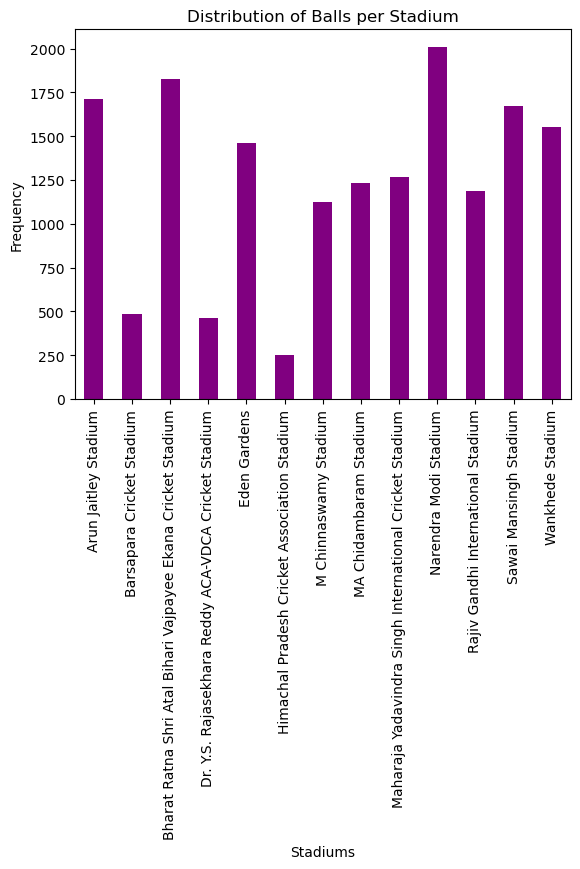

In [40]:
plt.figure()
df["Venue"].value_counts().sort_index().plot(kind="bar",color='purple')
plt.title("Distribution of Balls per Stadium")
plt.xlabel("Stadiums")
plt.ylabel("Frequency")
plt.show()

- From the above plot, in the `Narendra Modi Stadium` highest deliveries are delivered.
- Most of the matches are held in the `Narendra Modi Stadium`.

In [41]:
df['Match Date'].nunique()

58

In [42]:
df["Match Date"].dt.month_name().value_counts()

Match Date
April    8372
May      4604
March    2770
June      496
Name: count, dtype: int64

- 70 Matches are held in `58 Days`.
- These matches are held in `April`,`May`,`March`,`June`.
- Most of the matches are held in `April` month.

In [43]:
df['Bat_runs'].value_counts()

Bat_runs
1    6032
0    5932
4    2123
6    1209
2     917
3      27
5       2
Name: count, dtype: int64

- The Bat_runs concieved by the batters included `[0,1,2,3,4,5,6]`.
- From those most of the runs cam from singles(1).

In [44]:
df['Total_runs'].sum()

np.int64(24838)

- In total season total `24838` runs are concided.

In [45]:
df['Total_runs'].value_counts()

Total_runs
1    6833
0    5030
4    2140
6    1202
2     970
5      32
3      28
7       7
Name: count, dtype: int64

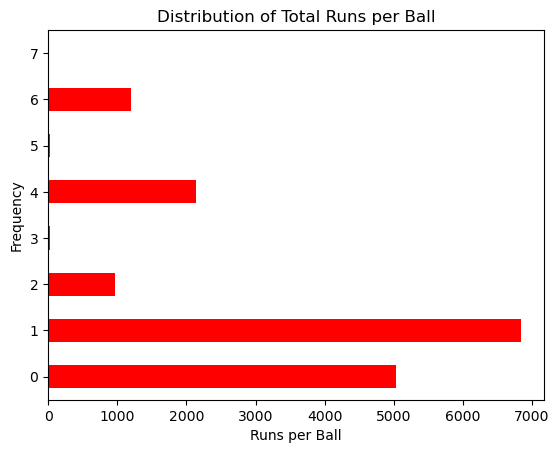

In [46]:
plt.figure()
df["Total_runs"].value_counts().sort_index().plot(kind="barh",color='r')
plt.title("Distribution of Total Runs per Ball")
plt.xlabel("Runs per Ball")
plt.ylabel("Frequency")
plt.show()

- Most runs came from the singles(1) and fours.

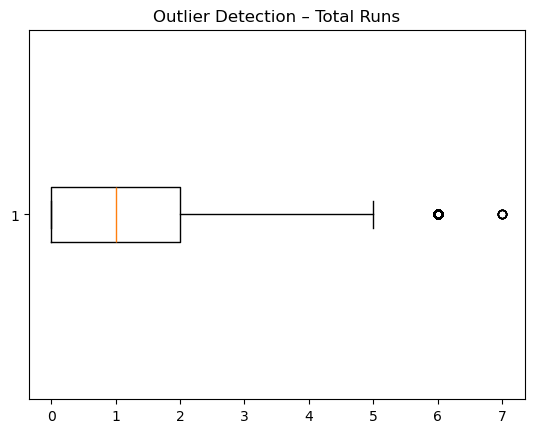

In [47]:
plt.figure()
plt.boxplot(df["Total_runs"], vert=False)
plt.title("Outlier Detection – Total Runs")
plt.show()

- If we observe the box plot, we have outliers as 6 and 7, but they are not outliers.

In [48]:
df['Bat_runs'].sum()

np.int64(23703)

- In `24838` runs, `23703` runs from the `Bat_runs`.

In [49]:
df['Extras'].sum()

np.int64(1135)

In [50]:
df['Extras'].value_counts()

Extras
0    15308
1      852
2       34
5       24
4       23
3        1
Name: count, dtype: int64

C:\Users\kasio\AppData\Local\Temp\ipykernel_20624\3684025155.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Extras"], palette=['b','g','y','purple','r','m'])


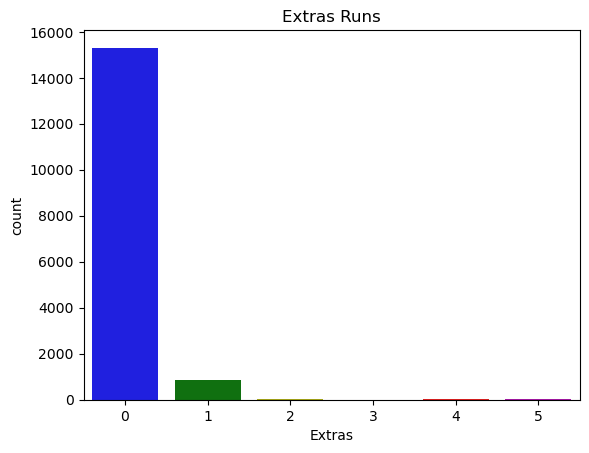

In [51]:
sns.countplot(x=df["Extras"], palette=['b','g','y','purple','r','m'])
plt.title("Extras Runs")
plt.show()

- Total `1135` runs came from extras.
- In ***`24838`*** runs, **`23703`** runs from the Bat_runs and **`1135`** from the Extra runs.

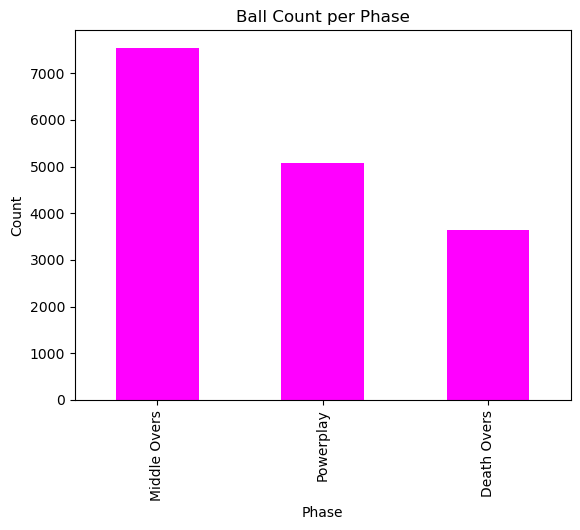

In [52]:
df["Phase"].value_counts().plot(kind="bar",color='magenta')
plt.title("Ball Count per Phase")
plt.xlabel("Phase")
plt.ylabel("Count")
plt.show()

- In Middle overs, most of the deliveries are delivered.

## Bivariate Analysis

In [53]:
vc=df[['Venue','City']].drop_duplicates()
vc

,Venue,City
0,Eden Gardens,Kolkata
223,Rajiv Gandhi International Stadium,Uppal
485,MA Chidambaram Stadium,Chepauk
727,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Visakhapatnam
973,Narendra Modi Stadium,Ahmedabad
1227,Barsapara Cricket Stadium,Guwahati
2668,Wankhede Stadium,Mumbai
2770,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow
2995,M Chinnaswamy Stadium,Bengaluru
3957,Maharaja Yadavindra Singh International Cricke...,Mullanpur


In [54]:
vc['Venue'].value_counts()

Venue
Maharaja Yadavindra Singh International Cricket Stadium         2
Rajiv Gandhi International Stadium                              1
MA Chidambaram Stadium                                          1
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium             1
Eden Gardens                                                    1
Narendra Modi Stadium                                           1
Barsapara Cricket Stadium                                       1
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium    1
Wankhede Stadium                                                1
M Chinnaswamy Stadium                                           1
Sawai Mansingh Stadium                                          1
Arun Jaitley Stadium                                            1
Himachal Pradesh Cricket Association Stadium                    1
Name: count, dtype: int64

In [55]:
df.loc[df['Venue']=='Maharaja Yadavindra Singh International Cricket Stadium','City']='Mullanpur'

In [56]:
df[['Venue','City']].drop_duplicates().value_counts()

Venue                                                         City         
Arun Jaitley Stadium                                          Delhi            1
Barsapara Cricket Stadium                                     Guwahati         1
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium  Lucknow          1
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium           Visakhapatnam    1
Eden Gardens                                                  Kolkata          1
Himachal Pradesh Cricket Association Stadium                  Dharamsala       1
M Chinnaswamy Stadium                                         Bengaluru        1
MA Chidambaram Stadium                                        Chepauk          1
Maharaja Yadavindra Singh International Cricket Stadium       Mullanpur        1
Narendra Modi Stadium                                         Ahmedabad        1
Rajiv Gandhi International Stadium                            Uppal            1
Sawai Mansingh Stadium           

- In univariate analysis we found that the total venue count and the cities count are not equal.
- For the **`Maharaja Yadavindra Singh International Cricket Stadium`** has two cities in the data.
- The two cities are `New Chandigarh` and `Mullanpur` we replaced the New Chandigarh with the `Mullanpur`.

In [57]:
df.groupby('Match')['Total_runs'].sum()

Match
1              351
2              528
3              309
4              420
5              475
              ... 
70             230
Eliminator     436
Final          374
Qualifier 1    101
Qualifier 2    410
Name: Total_runs, Length: 70, dtype: int64

In [58]:
df.groupby('Match')['Total_runs'].sum().median()

361.0

In [59]:
df.groupby(['Innings','Match'])['Total_runs'].sum().median()

186.0

- On an average, in every match together in both innings the score is 354 runs.
- For each innings the central tendency is 186 runs.

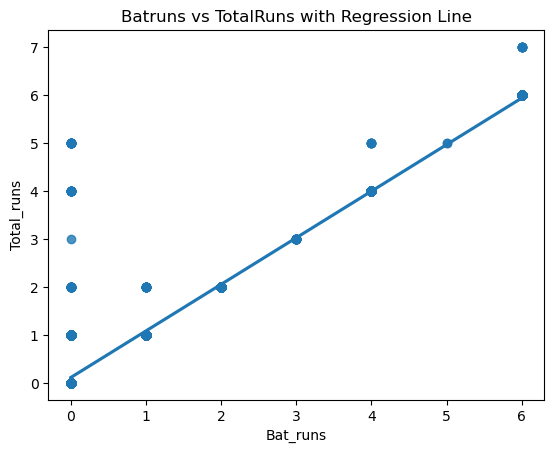

In [60]:
plt.figure()
sns.regplot(x=df['Bat_runs'], y=df['Total_runs'])

plt.title("Batruns vs TotalRuns with Regression Line")
plt.show()

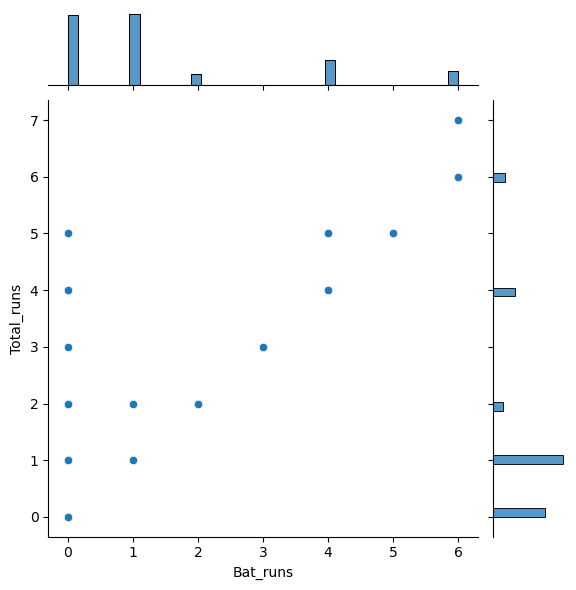

In [61]:
sns.jointplot(x=df['Bat_runs'], y=df['Total_runs'], kind='scatter')
plt.show()

- From the `Reg plot` and `joint plot` Bat_runs and Total_runs are linearly related.


In [62]:
df[['Extras','Total_runs']].corr()

,Extras,Total_runs
Extras,1.000000,0.031852
Total_runs,0.031852,1.000000


In [63]:
df[['Bat_runs','Total_runs']].corr()

,Bat_runs,Total_runs
Bat_runs,1.000000,0.982031
Total_runs,0.982031,1.000000


In [64]:
df[['Bat_runs','Total_runs','Extras']].corr()

,Bat_runs,Total_runs,Extras
Bat_runs,1.000000,0.982031,-0.157342
Total_runs,0.982031,1.000000,0.031852
Extras,-0.157342,0.031852,1.000000


- Correlation is performed between the `Total_runs vs Extras` , `Bat_runs vs Total_runs` and `'Bat_runs vs Total_runs vs Extras`.
- From this *Bat_runs and Total_runs* have `strong positive correlation`.
- *Extras and Total_runs* have `weak positive correlation`.
- *Bat_runs and Extras* have `weak negative correlation`
---
From this we can say the Bat_runs are highly impacting the Total_runs.

In [65]:
#Which team scored most runs overall
df.groupby('Batting Team')['Total_runs'].sum().sort_values(ascending=False)

Batting Team
Punjab Kings                   2939
Mumbai Indians                 2787
Gujarat Titans                 2690
Rajasthan Royals               2597
Royal Challengers Bengaluru    2547
Sunrisers Hyderabad            2519
Delhi Capitals                 2352
Lucknow Super Giants           2270
Chennai Super Kings            2249
Kolkata Knight Riders          1888
Name: Total_runs, dtype: int64

In [66]:
df.groupby('Batting Team')['Total_runs'].agg(['count','sum','mean','max'])

,count,sum,mean,max
Batting Team,,,,
Chennai Super Kings,1616,2249,1.391708,7
Delhi Capitals,1541,2352,1.526282,6
Gujarat Titans,1710,2690,1.573099,6
Kolkata Knight Riders,1309,1888,1.442322,6
Lucknow Super Giants,1490,2270,1.523490,7
Mumbai Indians,1805,2787,1.544044,7
Punjab Kings,1846,2939,1.592091,6
Rajasthan Royals,1673,2597,1.552301,6
Royal Challengers Bengaluru,1653,2547,1.540835,7


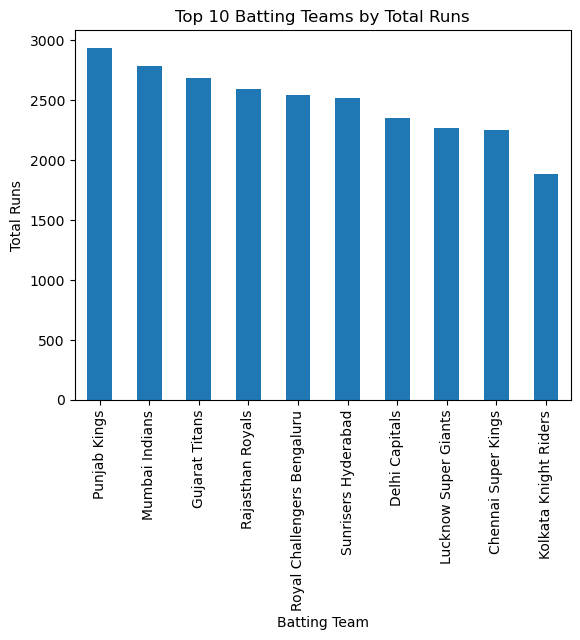

In [67]:
team_runs = (
    df.groupby("Batting Team")["Total_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
team_runs.plot(kind="bar")
plt.title("Top 10 Batting Teams by Total Runs")
plt.xlabel("Batting Team")
plt.ylabel("Total Runs")
plt.show()

- From the above analysis:
---
- Punjab Kings scored the most runs in the overall runs by a team in a series.
- Kolkatta Knight Riders scored the least runs on the overall runs by a team in a series

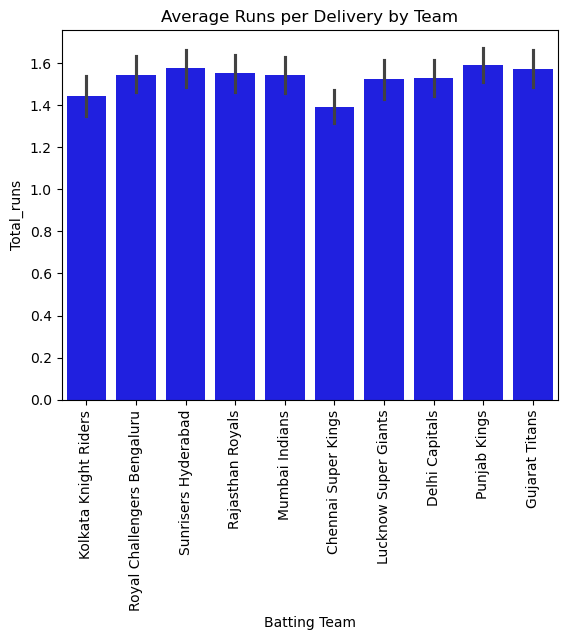

In [68]:
plt.figure()
sns.barplot(x='Batting Team', y='Total_runs', data=df, estimator='mean',color='b')
plt.xticks(rotation=90)
plt.title("Average Runs per Delivery by Team")
plt.show()

- PB has a higher average run rate per delivery compared to SRH, indicating stronger batting efficiency in IPL 2025.

In [69]:
df.groupby("Phase")["Total_runs"].agg(["mean","median","std"])

,mean,median,std
Phase,,,
Death Overs,1.710548,1.0,1.889276
Middle Overs,1.435371,1.0,1.665244
Powerplay,1.539069,1.0,1.862623


- Most of the teams are scoring runs in Death Overs and Power play

In [70]:
pd.pivot_table(
    df,
    values='Total_runs',
    index='Batting Team',
    columns='Innings',
    aggfunc='sum'
)

Innings,1,2
Batting Team,,
Chennai Super Kings,848,1401
Delhi Capitals,935,1417
Gujarat Titans,1224,1466
Kolkata Knight Riders,1079,809
Lucknow Super Giants,1531,739
Mumbai Indians,1738,1049
Punjab Kings,1737,1202
Rajasthan Royals,711,1886
Royal Challengers Bengaluru,1452,1095


In [71]:
toss_df = df[["Match", "Toss Winner"]].drop_duplicates()
toss_counts = toss_df["Toss Winner"].value_counts()
toss_counts

Toss Winner
Punjab Kings                   11
Delhi Capitals                  8
Mumbai Indians                  8
Royal Challengers Bengaluru     7
Rajasthan Royals                7
Chennai Super Kings             6
Kolkata Knight Riders           6
Gujarat Titans                  6
Sunrisers Hyderabad             6
Lucknow Super Giants            5
Name: count, dtype: int64

In [72]:
most_toss_wins = toss_counts.idxmax()
most_toss_wins_count = toss_counts.max()
most_toss_wins, most_toss_wins_count

('Punjab Kings', 11)

In [73]:
least_toss_wins = toss_counts.idxmin()
least_toss_wins_count = toss_counts.min()

least_toss_wins, least_toss_wins_count

('Lucknow Super Giants', 5)

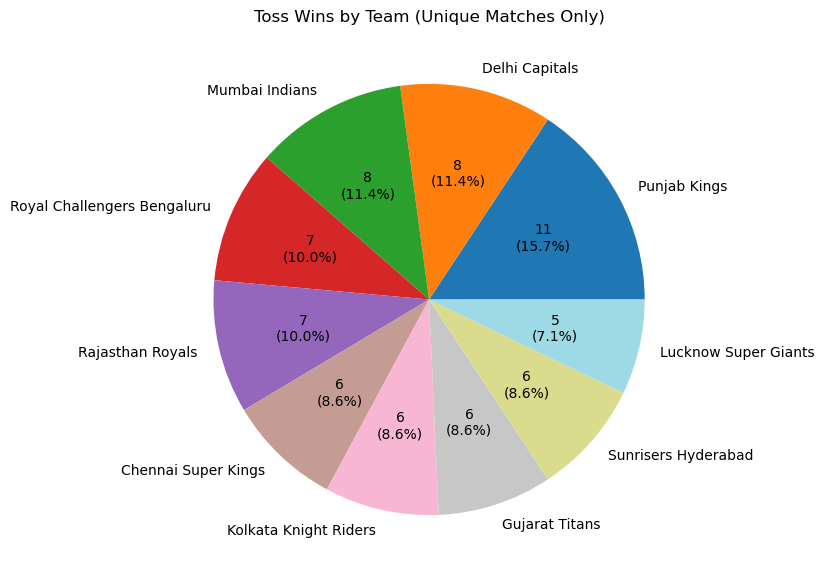

In [74]:
toss_counts.plot(
    kind="pie",
    figsize=(7,7),
    autopct=lambda p: f'{int(p * sum(toss_counts) / 100)}\n({p:.1f}%)',
    cmap='tab20'
)

plt.title("Toss Wins by Team (Unique Matches Only)")
plt.ylabel("")
plt.show()


- The above plot shows the winning percentage of toss by each team and how many times each team won the toss.
-  Among the all teams, `Punjab Kings` won the toss `11 times`. i.e., PB won the toss most times
- `Lucknow Super Giants` won the toss `5 times`. i.e., LSG won the toss least times.

In [75]:
df.groupby('Bowling Team')['Extras'].sum().sort_values(ascending=False)

Bowling Team
Rajasthan Royals               156
Mumbai Indians                 132
Gujarat Titans                 127
Punjab Kings                   117
Chennai Super Kings            115
Sunrisers Hyderabad            111
Delhi Capitals                 106
Lucknow Super Giants           101
Kolkata Knight Riders           87
Royal Challengers Bengaluru     83
Name: Extras, dtype: int64

- `Royal Challengers Bengaluru` and `Kolkata Knight Riders` conceded less extras when compared to other teams. i.e., It has the best bowlers.

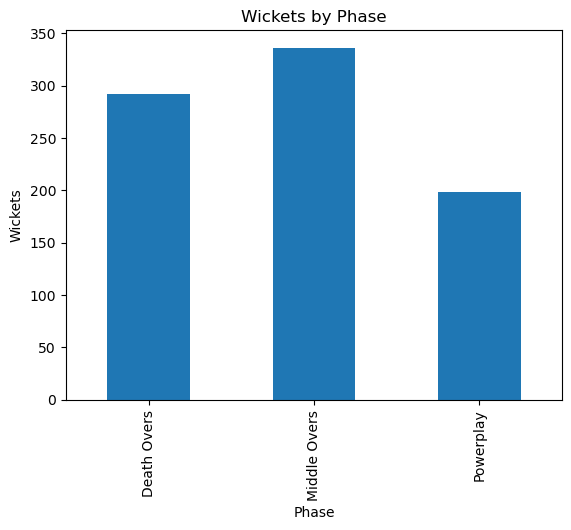

In [76]:
df.groupby("Phase")["Wicket"].sum().plot(kind="bar")
plt.title("Wickets by Phase")
plt.ylabel("Wickets")
plt.show()
#Middle overs are crucial for breaking partnerships.

- Bowlers are breaking the partnership mostly in  the `Middle Overs`.
- Wickets fall down in the series over the phase wise is high in middle over.
---
We can say that Middle overs are crucial for breaking partnerships.

### Multivariate Analysis

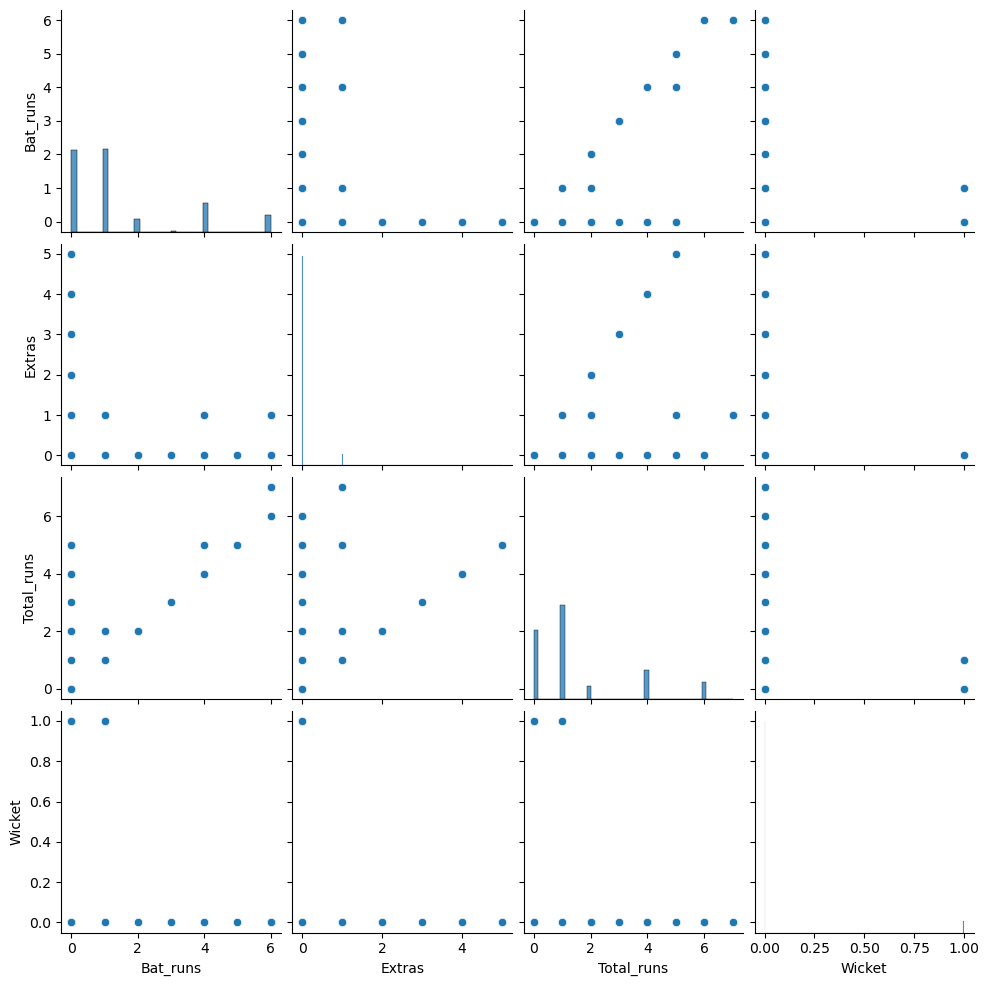

In [77]:
sns.pairplot(df[['Bat_runs','Extras','Total_runs','Wicket']])
plt.show()

- Fewer number of wickets are falling for the `Runouts`

In [78]:
team_match_df = df[["Match", "Batting Team", "Bowling Team"]].drop_duplicates()
team_match_long = pd.concat([
    team_match_df[["Match", "Batting Team"]]
        .rename(columns={"Batting Team": "Team"}), 
    team_match_df[["Match", "Bowling Team"]]
        .rename(columns={"Bowling Team": "Team"})
])
matches_played = (
    team_match_long
    .drop_duplicates()
    .groupby("Team")["Match"]
    .nunique()
    .sort_values(ascending=False)
)

matches_played

Team
Punjab Kings                   16
Mumbai Indians                 16
Royal Challengers Bengaluru    15
Chennai Super Kings            14
Rajasthan Royals               14
Gujarat Titans                 14
Delhi Capitals                 13
Lucknow Super Giants           13
Sunrisers Hyderabad            13
Kolkata Knight Riders          12
Name: Match, dtype: int64

- Punjab Kings played the most number of matches in the series including the playoffs. It has played 16 matches.
- Some of the teams are played 13 and KKR played 12 macthes because some matches are `Abonded` due to rain.

<Axes: >

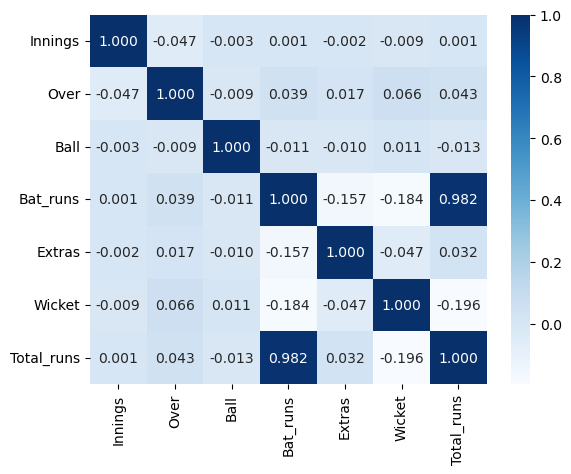

In [79]:
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(),annot=True, cmap="Blues", fmt=".3f")

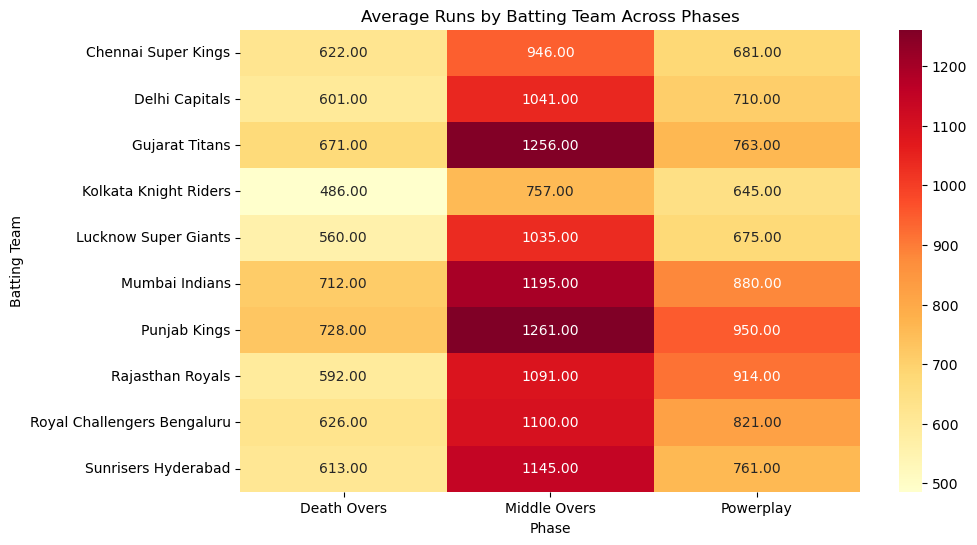

In [80]:
team_phase = df.pivot_table(
    values="Total_runs",
    index="Batting Team",
    columns="Phase",
    aggfunc="sum"
)

plt.figure(figsize=(10,6))
sns.heatmap(team_phase, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Average Runs by Batting Team Across Phases")
plt.show()

In [81]:
df.groupby("Bowling Team")["Wicket"].sum().sort_values(ascending=False)

Bowling Team
Mumbai Indians                 116
Royal Challengers Bengaluru     91
Gujarat Titans                  86
Punjab Kings                    84
Sunrisers Hyderabad             81
Chennai Super Kings             81
Kolkata Knight Riders           75
Delhi Capitals                  74
Lucknow Super Giants            70
Rajasthan Royals                68
Name: Wicket, dtype: int64

- In the series Mumbai Indians taken highest wickets then RCB, it shows that they both have the strong bowling unit.
- `Rajasthan Royals` taken fewer wickets it shows that it has weak bowling unit.

In [82]:
pivot_phase_innings = df.pivot_table(
    values="Total_runs",
    index=['Batting Team',"Innings"],
    columns="Phase",
    aggfunc="sum"
)
print(pivot_phase_innings)

Phase                                Death Overs  Middle Overs  Powerplay
Batting Team                Innings                                      
Chennai Super Kings         1                222           363        263
                            2                400           583        418
Delhi Capitals              1                292           376        267
                            2                309           665        443
Gujarat Titans              1                354           514        356
                            2                317           742        407
Kolkata Knight Riders       1                307           416        356
                            2                179           341        289
Lucknow Super Giants        1                434           658        439
                            2                126           377        236
Mumbai Indians              1                512           685        541
                            2         

<Figure size 640x480 with 0 Axes>

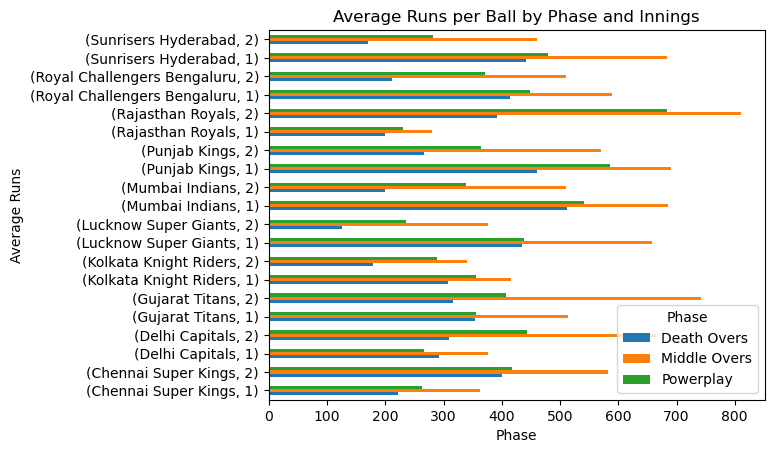

In [83]:
plt.figure()
pivot_phase_innings.plot(kind="barh")
plt.title("Average Runs per Ball by Phase and Innings")
plt.xlabel("Phase")
plt.ylabel("Average Runs")
plt.show()
#1st innings teams attack more in death overs

#2nd innings teams stabilize in middle overs

- In `1st Innings` most of the teams are scoring runs in `death and middle overs`.
- In `2nd Innings` most of the teams are scoring runs in` power play and middle overs`

In [84]:
toss_df = df[["Match", "Toss Winner", "Toss Decision"]].drop_duplicates()
toss_decision_counts = toss_df["Toss Decision"].value_counts()
most_selected = toss_decision_counts.idxmax()

most_selected

'Field'

The majority of teams opted to field first after winning the toss, indicating a preference for chasing targets.

In [85]:
match_scores = (
    df.groupby(["Match", "Innings", "Batting Team"])["Total_runs"]
      .sum()
      .reset_index()
)
winning_innings = (
    match_scores.loc[
        match_scores.groupby("Match")["Total_runs"].idxmax()
    ][["Match", "Innings"]]
)
innings_win_counts = winning_innings["Innings"].value_counts()
innings_win_counts

Innings
1    39
2    31
Name: count, dtype: int64

- First batting teams won the most of the matches.

### Final Predictions

In [86]:
playoff_matches = df["Match"].unique()[-4:]
playoff_matches

array(['Qualifier 1', 'Eliminator', 'Qualifier 2', 'Final'], dtype=object)

In [87]:
playoff_teams = pd.unique(
    df[df["Match"].isin(playoff_matches)]
    [["Batting Team", "Bowling Team"]]
    .values.ravel()
)
playoff_teams

array(['Punjab Kings', 'Royal Challengers Bengaluru', 'Mumbai Indians',
       'Gujarat Titans'], dtype=object)

The four teams qualified for the playoff are:
- **Punjab Kings**
- **Royal Challengers Bengaluru**
- **Mumbai Indians**
- **Gujarat Titans**

In [91]:
match_scores = (
    df.groupby(["Match", "Innings", "Batting Team"])["Total_runs"]
    .sum()
    .reset_index()
)
match_scores

,Match,Innings,Batting Team,Total_runs
0,1,1,Kolkata Knight Riders,174
1,1,2,Royal Challengers Bengaluru,177
2,2,1,Sunrisers Hyderabad,286
3,2,2,Rajasthan Royals,242
4,3,1,Mumbai Indians,151
...,...,...,...,...
130,Final,1,Royal Challengers Bengaluru,190
131,Final,2,Punjab Kings,184
132,Qualifier 1,1,Punjab Kings,101
133,Qualifier 2,1,Mumbai Indians,203


In [92]:
winner=match_scores.sort_values(by=['Match','Total_runs'],ascending=[True,False]).iloc[::2]
winner

,Match,Innings,Batting Team,Total_runs
1,1,2,Royal Challengers Bengaluru,177
2,2,1,Sunrisers Hyderabad,286
5,3,2,Chennai Super Kings,158
7,4,2,Delhi Capitals,211
8,5,1,Punjab Kings,243
...,...,...,...,...
125,69,1,Mumbai Indians,184
128,Eliminator,1,Mumbai Indians,228
130,Final,1,Royal Challengers Bengaluru,190
132,Qualifier 1,1,Punjab Kings,101


In [93]:
winners = match_scores.loc[
    match_scores.groupby("Match")["Total_runs"].idxmax()
][["Match", "Batting Team"]].rename(
    columns={"Batting Team": "Winner"}
)
winners

,Match,Winner
1,1,Royal Challengers Bengaluru
2,2,Sunrisers Hyderabad
5,3,Chennai Super Kings
7,4,Delhi Capitals
8,5,Punjab Kings
...,...,...
127,70,Royal Challengers Bengaluru
128,Eliminator,Mumbai Indians
130,Final,Royal Challengers Bengaluru
132,Qualifier 1,Punjab Kings


In [94]:
teams_played = pd.concat([
    df[["Match", "Batting Team"]].rename(columns={"Batting Team": "Team"}),
    df[["Match", "Bowling Team"]].rename(columns={"Bowling Team": "Team"})
]).drop_duplicates()
teams_played

,Match,Team
0,1,Kolkata Knight Riders
124,1,Royal Challengers Bengaluru
223,2,Sunrisers Hyderabad
356,2,Rajasthan Royals
485,3,Mumbai Indians
...,...,...
2668,12,Mumbai Indians
5701,25,Kolkata Knight Riders
11021,49,Chennai Super Kings
15294,70,Lucknow Super Giants


In [95]:
wins = winners["Winner"].value_counts().rename_axis("Team").reset_index(name="Wins")
played = teams_played["Team"].value_counts().rename_axis("Team").reset_index(name="Matches")
points_table = pd.merge(played, wins, on="Team", how="left").fillna(0)

points_table["Wins"] = points_table["Wins"].astype(int)
points_table["Losses"] = points_table["Matches"] - points_table["Wins"]
points_table["Win %"] = (points_table["Wins"] / points_table["Matches"]) * 100

points_table = points_table.sort_values("Wins", ascending=False)

points_table

,Team,Matches,Wins,Losses,Win %
0,Punjab Kings,16,12,4,75.000000
2,Royal Challengers Bengaluru,15,10,5,66.666667
1,Mumbai Indians,16,9,7,56.250000
3,Gujarat Titans,14,9,5,64.285714
7,Sunrisers Hyderabad,13,6,7,46.153846
6,Delhi Capitals,13,6,7,46.153846
8,Lucknow Super Giants,13,5,8,38.461538
4,Chennai Super Kings,14,5,9,35.714286
9,Kolkata Knight Riders,12,5,7,41.666667
5,Rajasthan Royals,14,3,11,21.428571


In [96]:
points_table[["Team", "Win %"]].sort_values("Win %", ascending=False)

,Team,Win %
0,Punjab Kings,75.000000
2,Royal Challengers Bengaluru,66.666667
3,Gujarat Titans,64.285714
1,Mumbai Indians,56.250000
7,Sunrisers Hyderabad,46.153846
6,Delhi Capitals,46.153846
9,Kolkata Knight Riders,41.666667
8,Lucknow Super Giants,38.461538
4,Chennai Super Kings,35.714286
5,Rajasthan Royals,21.428571


In [97]:
winning_innings = match_scores.loc[
    match_scores.groupby("Match")["Total_runs"].idxmax()
]
bat_success_rate = (
    (winning_innings["Innings"] == 1).mean() * 100)
chase_success_rate = (
    (winning_innings["Innings"] == 2).mean() * 100
)
print("Chase Success Rate:", chase_success_rate)
print("Batting Success Rate:", bat_success_rate)

Chase Success Rate: 44.285714285714285
Batting Success Rate: 55.714285714285715


In [98]:
team_match_runs = (
    df.groupby(["Match", "Batting Team"])["Total_runs"]
    .sum()
    .reset_index()
)

best_batting = (
    team_match_runs.groupby("Batting Team")["Total_runs"]
    .mean().reset_index()
    .sort_values(by='Total_runs',ascending=False)
)

best_batting.head(5)

,Batting Team,Total_runs
9,Sunrisers Hyderabad,193.769231
2,Gujarat Titans,192.142857
4,Lucknow Super Giants,189.166667
5,Mumbai Indians,185.800000
7,Rajasthan Royals,185.500000


In [99]:
team_conceded = (
    df.groupby(["Match", "Bowling Team"])["Total_runs"]
    .sum()
    .reset_index()
)

best_bowling = (
    team_conceded.groupby("Bowling Team")["Total_runs"]
    .mean().reset_index()
    .sort_values(by='Total_runs')
)

best_bowling.head(5)

,Bowling Team,Total_runs
5,Mumbai Indians,169.750000
8,Royal Challengers Bengaluru,169.928571
3,Kolkata Knight Riders,177.636364
0,Chennai Super Kings,180.769231
1,Delhi Capitals,185.307692


In [100]:
phase_runs = (
    df.groupby(["Batting Team", "Phase"])["Total_runs"]
    .sum()
    .unstack()
)
phase_runs["Dominant Phase"] = phase_runs.idxmax(axis=1)

phase_runs

Phase,Death Overs,Middle Overs,Powerplay,Dominant Phase
Batting Team,,,,
Chennai Super Kings,622,946,681,Middle Overs
Delhi Capitals,601,1041,710,Middle Overs
Gujarat Titans,671,1256,763,Middle Overs
Kolkata Knight Riders,486,757,645,Middle Overs
Lucknow Super Giants,560,1035,675,Middle Overs
Mumbai Indians,712,1195,880,Middle Overs
Punjab Kings,728,1261,950,Middle Overs
Rajasthan Royals,592,1091,914,Middle Overs
Royal Challengers Bengaluru,626,1100,821,Middle Overs


In [101]:
team_profile = df.groupby("Batting Team").agg(
    sum_runs=("Total_runs","sum"),
    wicket_rate=("Wicket","mean"),
    boundary_rate=("Total_runs", lambda x: (x>=4).mean())
)

team_profile.sort_values(by=['sum_runs','wicket_rate',"boundary_rate"], ascending=[False,False,False])

,sum_runs,wicket_rate,boundary_rate
Batting Team,,,
Punjab Kings,2939,0.053088,0.220477
Mumbai Indians,2787,0.046537,0.216620
Gujarat Titans,2690,0.040351,0.208187
Rajasthan Royals,2597,0.054393,0.215182
Royal Challengers Bengaluru,2547,0.048397,0.213551
Sunrisers Hyderabad,2519,0.051282,0.215134
Delhi Capitals,2352,0.052563,0.207657
Lucknow Super Giants,2270,0.051678,0.206040
Chennai Super Kings,2249,0.051980,0.172649


In [102]:
best_wicket_taker = (
    df[df['Wicket'] == 1]
    .groupby('Bowler')
    .size()
    .sort_values(ascending=False)
)

best_wicket_taker.head(10)

Bowler
Prasidh Krishna      26
Trent Boult          23
Noor Ahmad           22
Josh Hazlewood       22
Jasprit Bumrah       21
Arshdeep Singh       20
Sai Kishore          18
Bhuvneshwar Kumar    17
Krunal Pandya        17
Vaibhav Arora        17
dtype: int64

In [88]:
# Final match number
final_df = df[df["Match"] =='Final']

final_scores = (
    final_df.groupby(["Innings", "Batting Team"])["Total_runs"]
    .sum()
    .reset_index()
)
final_scores

,Innings,Batting Team,Total_runs
0,1,Royal Challengers Bengaluru,190
1,2,Punjab Kings,184


In [ ]:
champion=final_scores.loc[
    final_scores["Total_runs"].idxmax()]["Batting Team"
]
champion

- `Champion` of the IPL 2025 is **`Royal Challengers Bengaluru`**

In [ ]:
runner_up = final_scores.loc[
    final_scores["Total_runs"].idxmin(), "Batting Team"
]
runner_up

- `Runner Up` of the IPL 2025 is **`Punjab Kings`**

In [103]:
orange_cap = (
    df.groupby(["Batter"])["Bat_runs"]
    .sum().reset_index()
    .sort_values(by='Bat_runs',ascending=False)
)

orange_cap[['Batter']].head(1)

,Batter
21,B Sai Sudharsan


In [104]:
purple_cap = (
    df.groupby("Bowler")["Wicket"]
    .sum().reset_index()
    .sort_values(by='Wicket',ascending=False)
)

purple_cap[['Bowler']].head(1)

,Bowler
77,Prasidh Krishna


In [105]:
match_team_scores = (
    df.groupby(["Match", "Innings", "Batting Team"])["Total_runs"]
      .sum()
      .reset_index()
).sort_values(by='Total_runs',ascending=False)
match_team_scores = match_team_scores.rename(columns={
    "Batting Team": "Team",
    "Total_runs": "Team Score"
})
match_team_scores.head()

,Match,Innings,Team,Team Score
2,2,1,Sunrisers Hyderabad,286
123,68,1,Sunrisers Hyderabad,278
51,27,2,Sunrisers Hyderabad,247
50,27,1,Punjab Kings,245
8,5,1,Punjab Kings,243


In [106]:
most_sixes = (
    df[df["Bat_runs"] == 6]
    .groupby("Batter")
    .size()
    
    .sort_values(ascending=False)
)
most_sixes.head(10)

Batter
Shreyas Iyer         38
Suryakumar Yadav     36
Nicholas Pooran      35
Yashasvi Jaiswal     28
Abhishek Sharma      28
Riyan Parag          26
Heinrich Klaasen     25
Shubman Gill         24
Mitchell Marsh       24
Prabhsimran Singh    24
dtype: int64

In [107]:
player_match_runs = (
    df.groupby(["Match", "Batter",'Bowling Team'])["Bat_runs"]
    .sum()
    .reset_index()
)
player_match_runs.sort_values(by='Bat_runs',ascending=False).head(10)

,Match,Batter,Bowling Team,Bat_runs
411,27,Abhishek Sharma,Punjab Kings,141
865,60,KL Rahul,Gujarat Titans,112
863,60,B Sai Sudharsan,Delhi Capitals,108
20,2,Ishan Kishan,Rajasthan Royals,106
975,68,Heinrich Klaasen,Kolkata Knight Riders,105
345,22,Priyansh Arya,Chennai Super Kings,103
700,47,Vaibhav Sooryavanshi,Gujarat Titans,102
82,5,Shreyas Iyer,Gujarat Titans,97
91,6,Quinton de Kock,Rajasthan Royals,97
536,35,Jos Buttler,Delhi Capitals,97
